# 2-Photon Calcium Imaging Binarization Pipeline

Demonstrates binarizing two-photon calcium data using `binarize2pcalcium`.
Uses the built-in simulation module to generate realistic GCaMP6f traces
with photon shot noise and slow baseline drift.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from binarize2pcalcium import binarize, BinarizationResult
from binarize2pcalcium.data_simulation import (
    SimulationConfig,
    simulate_calcium_data,
    simulate_and_binarize,
)

print("Setup complete.")

Setup complete.


## 1. Simulate realistic 2P data

GCaMP6f kinetics: 80 ms rise, 600 ms decay, ~30% dF/F peaks,
Poisson shot noise + Gaussian read noise, slow baseline drift.

In [2]:
cfg = SimulationConfig(
    n_cells=30,
    n_timepoints=9000,        # 5 min @ 30 Hz
    sample_rate=30.0,
    tau_rise_mean=0.08,       # GCaMP6f rise
    tau_decay_mean=0.6,       # GCaMP6f decay
    amplitude_mean=0.30,      # 30 % dF/F
    baseline_photons=300.0,   # photons / frame
    read_noise_std=4.0,
    event_rate=0.04,          # ~2.4 events / min / cell
    drift_scale=0.02,         # slow baseline wander
    seed=42,
)

F_noisy, dff_true = simulate_calcium_data(cfg)
print(f"F shape: {F_noisy.shape}  |  dF/F range: [{dff_true.min():.3f}, {dff_true.max():.3f}]")

F shape: (30, 9000)  |  dF/F range: [0.000, 0.371]


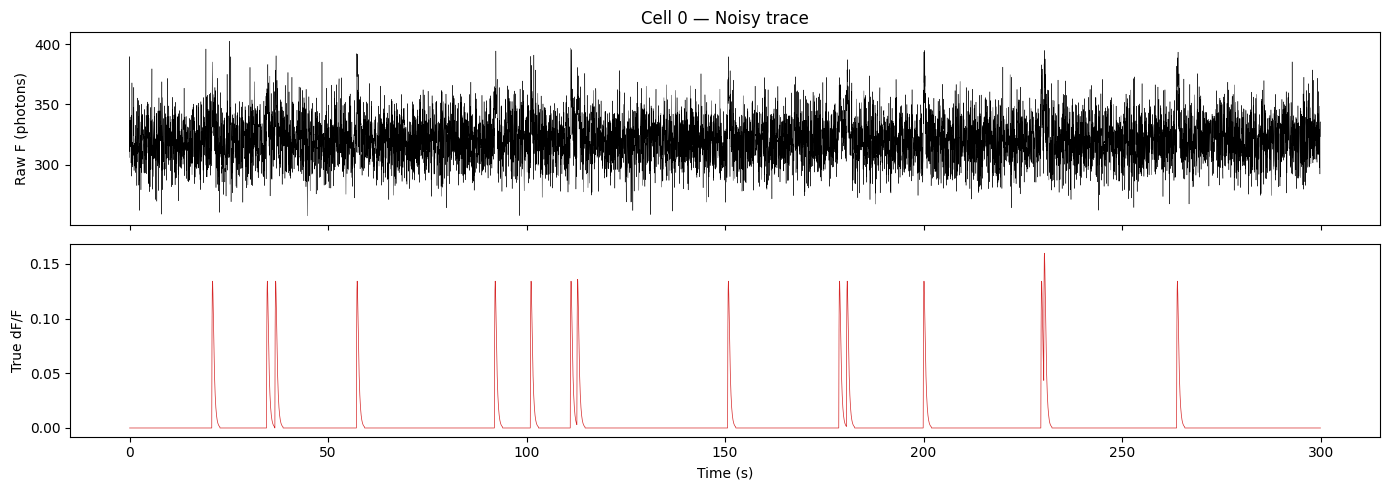

In [3]:
cell_id = 0
t = np.arange(cfg.n_timepoints) / cfg.sample_rate
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax1.plot(t, F_noisy[cell_id], linewidth=0.3, color='k')
ax1.set_ylabel('Raw F (photons)'); ax1.set_title(f'Cell {cell_id} — Noisy trace')
ax2.plot(t, dff_true[cell_id], linewidth=0.5, color='C3')
ax2.set_ylabel('True dF/F'); ax2.set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

## 2. Run the binarization pipeline

In [4]:
result, event_gt, dff_clean = simulate_and_binarize(cfg, binarize_kwargs=dict(
    high_cutoff=0.5,               # 2P default from source
    percentile_threshold=0.999,
    dff_min=0.05,
    verbose=True,
))

print(f"Onphase: {result.onphase.sum():,}  |  Upphase: {result.upphase.sum():,}  |  GT: {event_gt.sum():,}")

Running binarization pipeline:
  data_type=2p, sample_rate=30.0 Hz
  high_cutoff=0.5 Hz, detrend_order=1
  Input shape: (30, 9000)


model filter: remove bleaching or trends: 100%|██████████| 30/30 [00:00<00:00, 1695.24it/s]


  Computing thresholds...


fitting mode to physics: 100%|██████████| 30/30 [00:00<00:00, 114.96it/s]


  Binarizing onphase...


binarizing continuous traces: 100%|██████████| 30/30 [00:00<00:00, 17955.07it/s]


  Binarizing upphase...


binarizing continuous traces: 100%|██████████| 30/30 [00:00<00:00, 14428.29it/s]

  Done. Onphase events: 510, Upphase events: 203
Onphase: 510.0  |  Upphase: 203.0  |  GT: 19,795


## 3. Single-cell visualisation

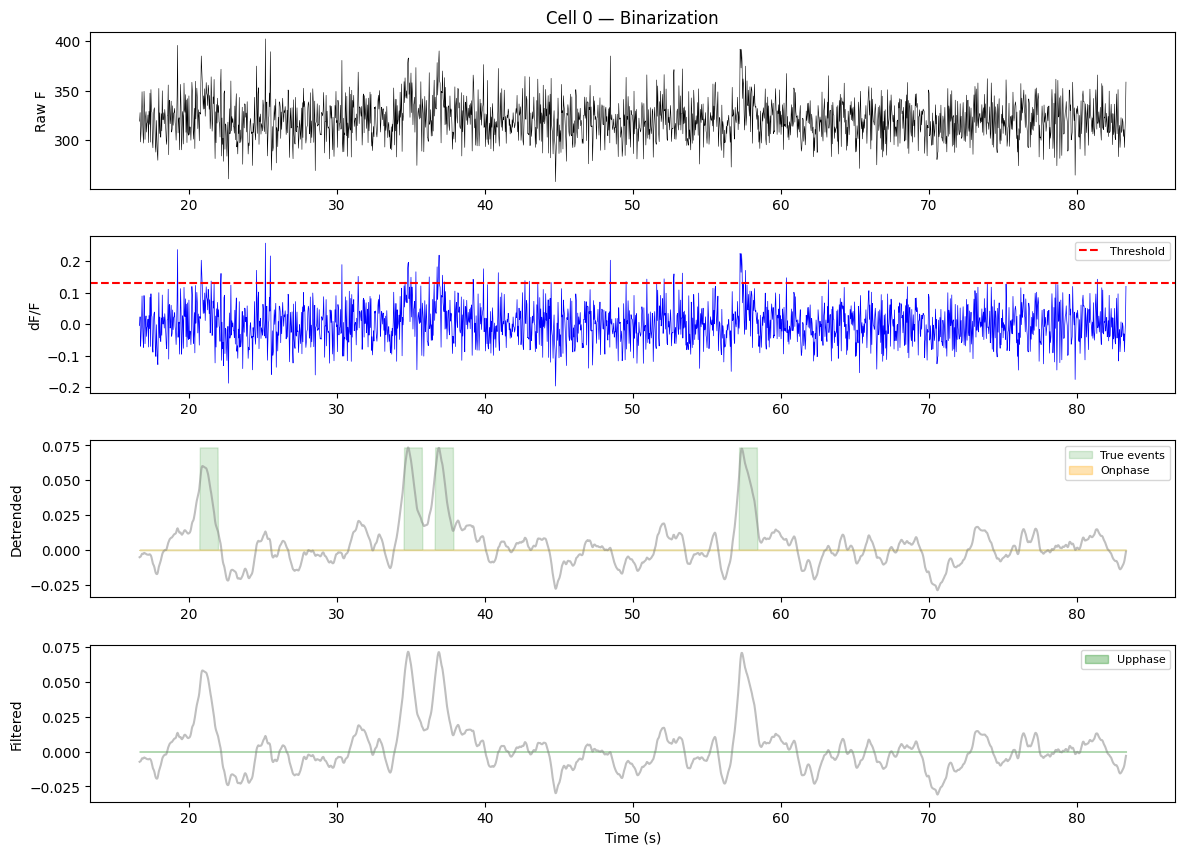

In [5]:
cell_id = 0
t = np.arange(result.F_raw.shape[1]) / cfg.sample_rate
zoom = slice(500, 2500)

fig = plt.figure(figsize=(14, 10))
gs = GridSpec(4, 1, figure=fig, hspace=0.3)

ax0 = fig.add_subplot(gs[0])
ax0.plot(t[zoom], result.F_raw[cell_id, zoom], 'k', linewidth=0.4)
ax0.set_ylabel('Raw F'); ax0.set_title(f'Cell {cell_id} — Binarization')

ax1 = fig.add_subplot(gs[1])
ax1.plot(t[zoom], result.dff[cell_id, zoom], 'b', linewidth=0.5)
ax1.axhline(y=result.thresholds[cell_id], color='r', linestyle='--', label='Threshold')
ax1.set_ylabel('dF/F'); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[2])
ymax = result.F_detrended[cell_id, zoom].max()
ax2.plot(t[zoom], result.F_detrended[cell_id, zoom], 'gray', alpha=0.5)
ax2.fill_between(t[zoom], 0, event_gt[cell_id, zoom] * ymax,
                 alpha=0.15, color='green', label='True events')
ax2.fill_between(t[zoom], 0, result.onphase[cell_id, zoom] * ymax,
                 alpha=0.3, color='orange', label='Onphase')
ax2.set_ylabel('Detrended'); ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[3])
ymax = result.F_filtered[cell_id, zoom].max()
ax3.plot(t[zoom], result.F_filtered[cell_id, zoom], 'gray', alpha=0.5)
ax3.fill_between(t[zoom], 0, result.upphase[cell_id, zoom] * ymax,
                 alpha=0.3, color='green', label='Upphase')
ax3.set_ylabel('Filtered'); ax3.set_xlabel('Time (s)')
ax3.legend(fontsize=8)

plt.show()

## 4. Raster plot

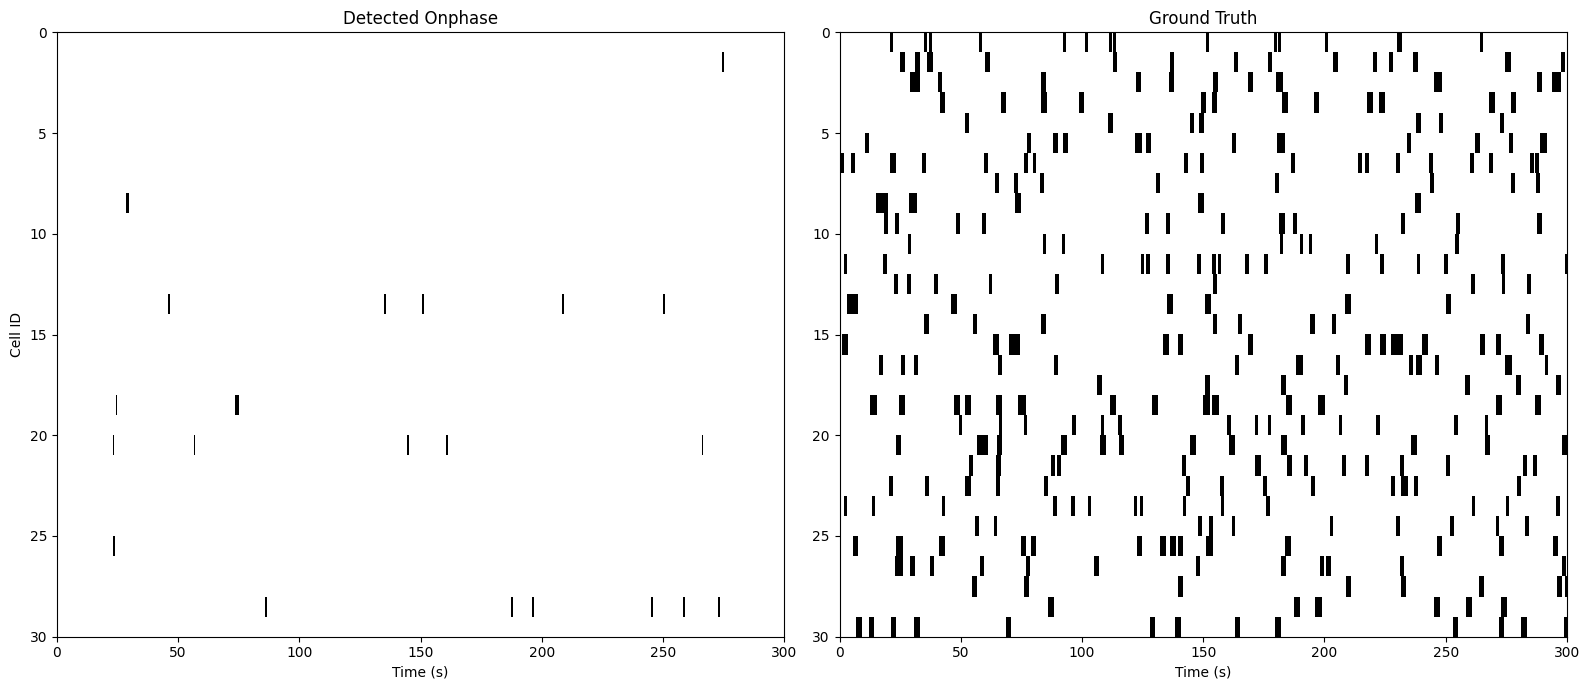

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, data, title in zip(axes,
    [result.onphase, event_gt],
    ['Detected Onphase', 'Ground Truth']):
    ax.imshow(data, aspect='auto', cmap='Greys', interpolation='none',
              extent=[0, data.shape[1] / cfg.sample_rate, data.shape[0], 0])
    ax.set_xlabel('Time (s)'); ax.set_title(title)
axes[0].set_ylabel('Cell ID')
plt.tight_layout(); plt.show()

## 5. Using a config file

In [8]:
import yaml
with open('../config/2p_pipeline.yaml') as f:
    params = yaml.safe_load(f)
result = binarize(F_noisy, **{k: v for k, v in params.items() if v is not None})
print(f"Used config: sample_rate={params['sample_rate']} Hz")

binarizing continuous traces: 100%|██████████| 30/30 [00:00<00:00, 21516.61it/s]

Used config: sample_rate=30 Hz
